### Time-Series Quiz
Datafile - Stocks

*Stock Market* a market place for investors to buy / sell the stocks or IPOs and such for investments and/or seeking investors. There are sules and regulations in place to ensure fair and orderly manner.

We are working on Netflix Stocks from around the world. The dataset contains stock price values from 2018-2022. Here the problem statement is :  
*the aim is to use ARIMA modelling to predict these stock prices as well as forecasting the stock price values for the next 30 days.*


The Stock market analysis can be broadly divided into two categories:
- *Fundamental analysis* assessing the company's potential profitablilty by analyzing it's current business and market.
- *Technical analysis* involves studying charts and statistical data to identify patterns and trends in the stock market. This method may be good for 2-3 months predictions but is not a reliable system for predicting long-term variations.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import chardet

filepath = r'D:\NFLX.csv'

# Read a sample of the file to detect encoding
with open(filepath, 'rb') as f:
    rawdata = f.read(100000) # Read up to 100KB for detection

result = chardet.detect(rawdata)
detected_encoding = result['encoding']
confidence = result['confidence']

if detected_encoding:
    print(f"Detected encoding: {detected_encoding} with confidence: {confidence}")
    try:
        nf_stock= pd.read_csv(filepath, encoding=detected_encoding)
        print("Successfully read with detected encoding.")
    except UnicodeDecodeError:
        print(f"Detected encoding '{detected_encoding}' failed, try another.")
else:
    print("Could not reliably detect encoding.")

Detected encoding: ascii with confidence: 1.0
Successfully read with detected encoding.


In [24]:
nf_stock

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


**Key points to be observed**  
1. The dataset contains varrious variables such as Date, Open/Close Values, High/Lows and Volumes of the stock.
2. *Open & Close* represent the opening and closing values of the script stock on the particular date.
3. *High & Low* are the minimum and maximum value of teh stock.
4. *Volume* is the number of stocks traded on the day overall.
5. *Adj. Close* is the true close value aftet the stock splits, bonuses, dividends, rights issued, removing illegal trades, etc.

Here ***Adj. Close*** will be the ***target column***

It is also observed that there are values missing for Holidays and weekends in the date sequence. We will work around that.

In [25]:
print(f"Shape: ")
print(nf_stock.shape)

print(f"Null Values: ")
print(nf_stock.isnull().sum())

print(f"\n Duplicates:")
print(nf_stock.duplicated().sum())

Shape: 
(1009, 7)
Null Values: 
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

 Duplicates:
0


In [26]:
print(nf_stock.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB
None


Setting the Date column as the index.

In [27]:
nf_stock["Date"]= pd.to_datetime(nf_stock["Date"], errors='coerce')   # convert to Date TIme
nf_stock.set_index("Date", inplace=True)       # set the date column as the index
nf_stock.sort_index(inplace=True, ascending=True)      # sort as per the date

In [28]:
nf_stock.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


Since we shall be working with the *Date* and the *Adj. Close* columns only, we can drop the rest of the data for proceeding further.

In [29]:
nf_stock= nf_stock.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1)
nf_stock

,Adj Close
Date,
2018-02-05,254.259995
2018-02-06,265.720001
2018-02-07,264.559998
2018-02-08,250.100006
2018-02-09,249.470001
...,...
2022-01-31,427.140015
2022-02-01,457.130005
2022-02-02,429.480011


**Stationarity Analysis** methods
1. Augmented Dickey-Fuller (ADF) Test
2. Line Plot
3. Seasonal Decompose

*(use any or all as needed)*

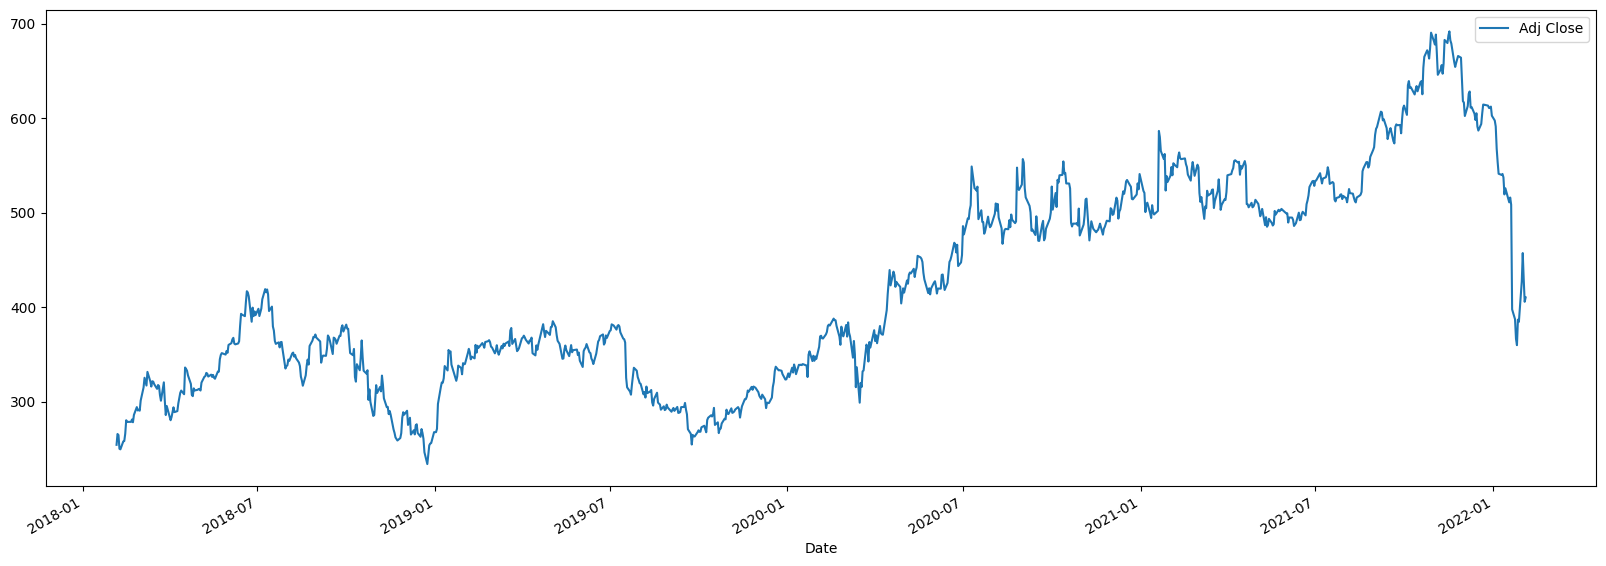

In [30]:
# Check the Plot
nf_stock.plot(figsize= (20,7))
plt.legend()
plt.show()

We observe that there is a small exponential growth, not much big though but also there is a steep drop. There is no need for a logrithmic transformation since there is a varying - almost consistent trend.

In [31]:
# Running AD Fuller test

from statsmodels.tsa.stattools import adfuller
adf_result= adfuller(nf_stock)

# Display results
print("  AD-Fuller Test Results\n  -----------------------")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

# Hypothesis testing
print("\n\n Hypothesis Testing\n -------------------")
if(adf_result[1]>0.05):
    print("The data is not stationary")
else:
    print("The data is stationary")

  AD-Fuller Test Results
  -----------------------
ADF Statistic: -1.8125906878289957
p-value: 0.3742289256820758
Critical Values: {'1%': np.float64(-3.436893045520188), '5%': np.float64(-2.8644287878535146), '10%': np.float64(-2.568308127138936)}


 Hypothesis Testing
 -------------------
The data is not stationary


*Interpreting the Results*  
***ADF Statistic:*** A more negative value indicates stronger evidence against the null hypothesis (non-stationarity).  
***p-value:*** If the p-value is less than your significance level (e.g., 0.05), you reject the null hypothesis, concluding the series is stationary.  
***Critical Values:*** Compare the ADF statistic with these values to determine stationarity.

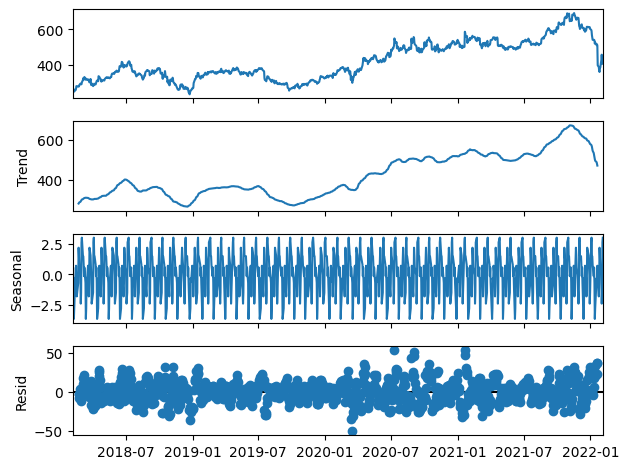

In [32]:
# Checking the data with seasonal decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

sd_result= seasonal_decompose(nf_stock, model='additive', period=22)    # period is taken to be 22 days because trade days are excluding the weekends 

sd_result.plot()
plt.show()

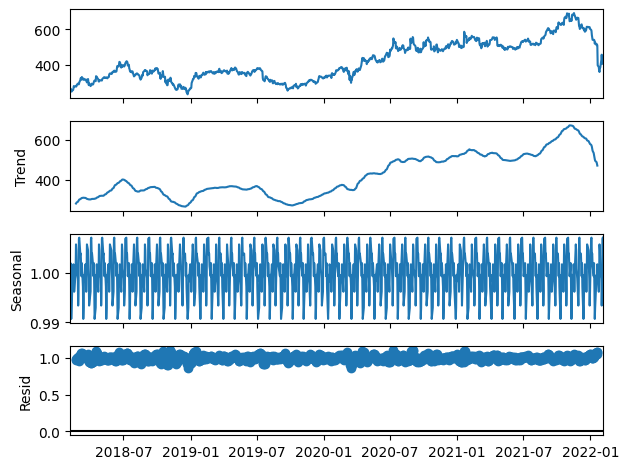

In [33]:
sd_result= seasonal_decompose(nf_stock, model='multiplicative', period=22)       # period is taken to be 22 days because trade days are excluding the weekends 

sd_result.plot()
plt.show()

*We Observe that*  
There is a stationary trend upto 2020 then upto its rising and again a dip beyond 2022  
seasonlity seems fairly repeatable  
in Residuals, it is quiet random and there are a few outliers.

Since there is no need of transformation. We check for shift data for stationarity.

In [34]:
new_data= nf_stock - nf_stock.shift(1)
new_data.dropna(inplace=True)

<Axes: xlabel='Date'>

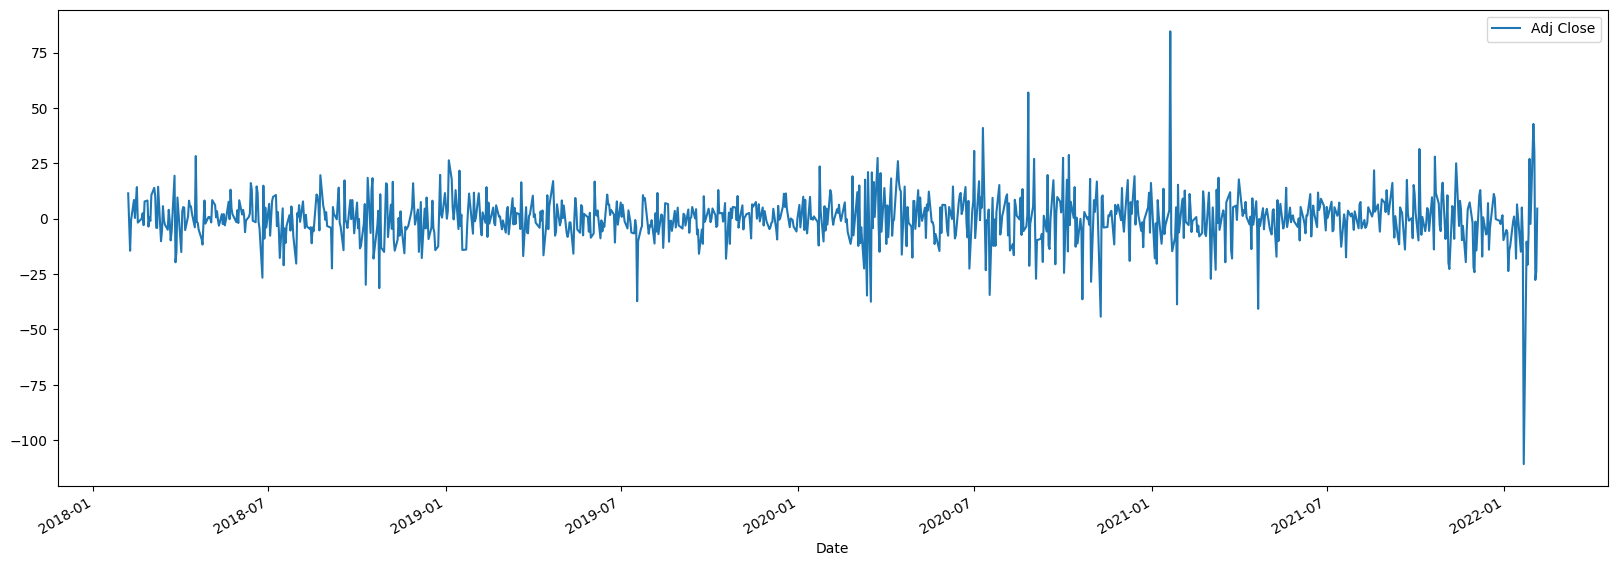

In [35]:
new_data.plot(figsize=(20,7))

In [36]:
adf_result= adfuller(new_data)

# Display results
print("  AD-Fuller Test Results\n  -----------------------")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

# Hypothesis testing
print("\n\n Hypothesis Testing\n -------------------")
if(adf_result[1]>0.05):
    print("The data is not stationary")
else:
    print("The data is stationary")

  AD-Fuller Test Results
  -----------------------
ADF Statistic: -14.242275992929107
p-value: 1.5304022754298954e-26
Critical Values: {'1%': np.float64(-3.436893045520188), '5%': np.float64(-2.8644287878535146), '10%': np.float64(-2.568308127138936)}


 Hypothesis Testing
 -------------------
The data is stationary


### Model Building

ARIMA - p, d, q
- *ar* Auto Regression (past values) - p
- *i* differencing order / values - d
- *ma* Moving Averages (past errors) - q

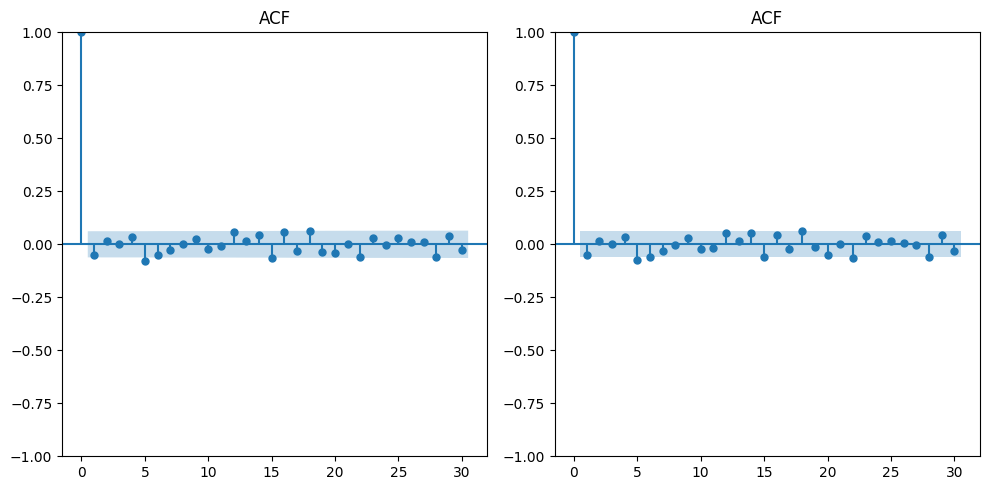

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes= plt.subplots(1,2, figsize= (10,5))

plot_acf(new_data['Adj Close'], ax=axes[0], lags=30)
axes[0].set_title("ACF")

plot_pacf(new_data['Adj Close'], ax=axes[1], lags=30)
axes[1].set_title("ACF")

plt.tight_layout()
plt.show()

As soon as the values go towards the Zero, its effect diminishes. So the further from the Zero and within the blue range are considewred . Above, we can estimate the values of p & q. Iter tools also help in deciding the values of p,q.

In [38]:
# Running Iter tools, we split the data to train-test

train_size= int(len(nf_stock)*0.8)  # 80% is considered as the training size

train_df= nf_stock['Adj Close'][:train_size]
test_df= nf_stock['Adj Close'][train_size:]

In [39]:
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

p= range(0,10)  # Auto Regression (past values)
d= range(1,2)   # differencing order
q= range(0,9)   # moving average (past errors)

pdq= list(itertools.product(p,d,q))
rmse= []
order1= []

for i in pdq:
    model= ARIMA(train_df, order=i)
    model_fit= model.fit()
    pred= model_fit.predict(start= len(train_df), end= len(train_df)+len(test_df)-1)
    error= np.sqrt(mean_squared_error(test_df, pred))

    order1.append(i)
    rmse.append(error)

result = pd.DataFrame(index=order1, data=rmse, columns=["RMSE score"])


C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored

In [40]:
result.sort_values(by="RMSE score")

,RMSE score
"(7, 1, 8)",70.390976
"(8, 1, 4)",70.406948
"(9, 1, 7)",70.428840
"(7, 1, 6)",70.429037
"(9, 1, 8)",70.441433
...,...
"(8, 1, 5)",71.383976
"(5, 1, 6)",71.490664
"(5, 1, 7)",72.793628
"(7, 1, 5)",73.167946


We see the lease rms error is at 70.39... so we take the pdq values at (7,1,8)

In [41]:
model1= ARIMA(nf_stock['Adj Close'], order=(7,1,8))
result= model1.fit()
nf_stock['ARIMA_Predicted']= result.predict()
nf_stock

C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored

,Adj Close,ARIMA_Predicted
Date,,
2018-02-05,254.259995,0.000000
2018-02-06,265.720001,254.258456
2018-02-07,264.559998,265.150177
2018-02-08,250.100006,264.736047
2018-02-09,249.470001,250.635061
...,...,...
2022-01-31,427.140015,393.742400
2022-02-01,457.130005,424.428995
2022-02-02,429.480011,454.256195


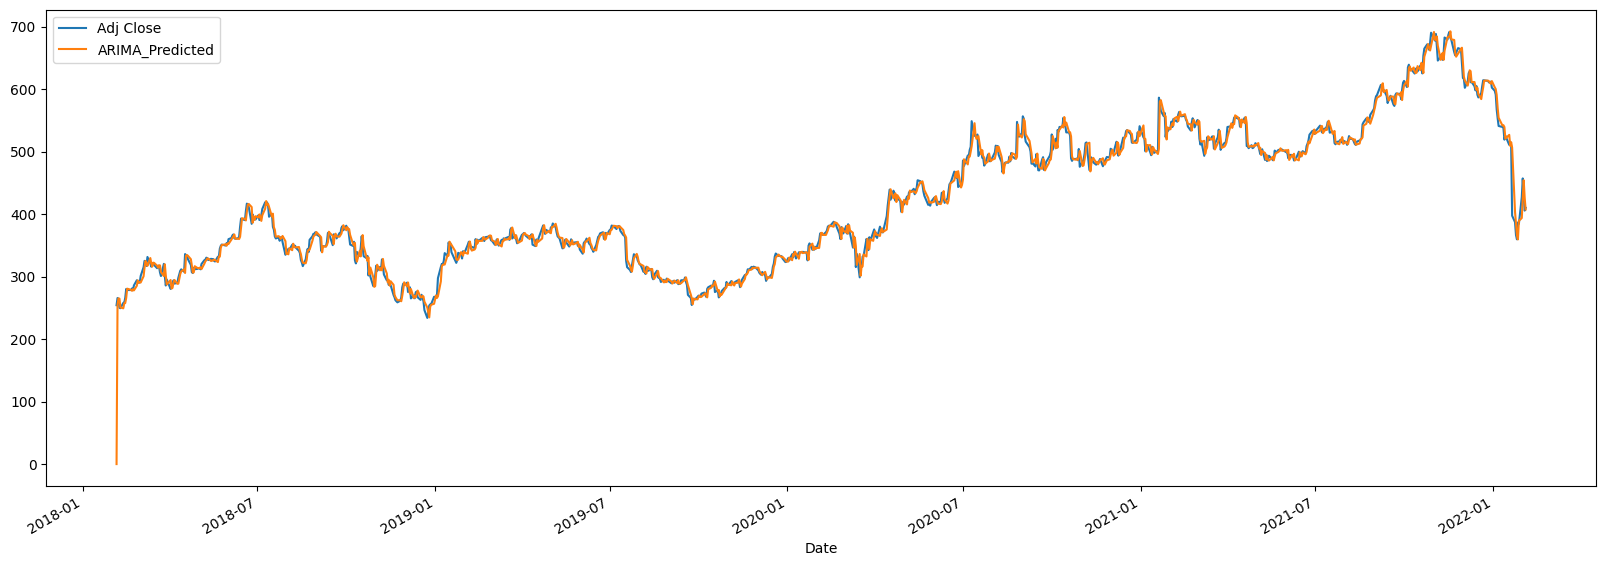

In [42]:
nf_stock[['Adj Close', 'ARIMA_Predicted']].plot(figsize=(20,7))
plt.show()

Above we can see the model has predicted in line with the actual 

In [43]:
forecast= result.get_forecast(steps=30) # predict for 30 days

forecast_value= forecast.predicted_mean
forecast_value


C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Harpreet\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


1009    409.228157
1010    403.595140
1011    398.243135
1012    397.944611
1013    403.044486
1014    402.108043
1015    400.340035
1016    397.542893
1017    402.973273
1018    406.791526
1019    408.280630
1020    405.620640
1021    405.689146
1022    409.695742
1023    411.330159
1024    410.555470
1025    405.772966
1026    406.544249
1027    406.982246
1028    408.330181
1029    404.258781
1030    402.096578
1031    402.173601
1032    404.238325
1033    404.843554
1034    402.220382
1035    402.468387
1036    403.350772
1037    407.091348
1038    406.065630
Name: predicted_mean, dtype: float64

The above values are the predicted values beyond the 1009 input values for the next 30 days.